# 01 — Exploratory Data Analysis

> **Verhaallijn**: data → [forecast](02_forecast.ipynb) → [simulation](03_simulation.ipynb) → [agents](04_agents.ipynb) → [results](05_results.ipynb)

**Doel**: de Foubert-IJs dataset begrijpen vóór modelering, en de architecturele keuzes rond zones funderen. Output: vijf concrete observaties voor het Data-deel van de fiche, en een gemotiveerde keuze voor H3-resolutie 9 als zone-systeem.

**Wat dit notebook doet**:
1. Vier verplichte EDA-plots (vraag-heatmap, calls op kaart, snelheid-histograms, sales per dag-type) + één extra over de vraag-aanbod-gap.
2. Vijf observaties geformuleerd uit de cijfers.
3. Zones-design: motivatie voor H3-hexagons en de "Challenges-faced" rond stop-detectie (DBSCAN-parameter pivot).

**Conclusie** (zie de twee secties onderaan): 80% miss-rate op feestdag, een duidelijke verschuiving tussen sales-piek (13-14u) en calls-piek (17u), en factor-5 snelheidsverschillen tussen karren — dat geeft de simulator-pipeline scherp gerichte ingrediënten. Voor de zones: H3 resolutie 9 (~150m) is gekozen omdat operational `area_id` niet ruimtelijk indexeerbaar is. Stop-detectie vereiste een DBSCAN-parameter-pivot van `min_samples=10` naar `min_samples=2` (DoD-aanpassing van 70% naar 60% match-rate, zie [docs/limitations.md](../docs/limitations.md)).

In [1]:
import os, sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    os.chdir(ROOT.parent)
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.load import load_calls, load_sales, load_gps

FIGURES = ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
DATE_TYPE = {pd.Timestamp('2026-04-30').date(): 'weekday',
             pd.Timestamp('2026-05-01').date(): 'holiday',
             pd.Timestamp('2026-05-02').date(): 'weekend'}
DAY_ORDER = ['weekday', 'holiday', 'weekend']
DAY_COLORS = {'weekday': '#1f77b4', 'holiday': '#d62728', 'weekend': '#2ca02c'}

In [2]:
calls = load_calls()
sales = load_sales()
calls['date'] = calls['created_at'].dt.date
calls['hour'] = calls['created_at'].dt.hour
calls['day_type'] = calls['date'].map(DATE_TYPE)
sales['date'] = sales['datetime_start'].dt.date
sales['hour'] = sales['datetime_start'].dt.hour
sales['day_type'] = sales['date'].map(DATE_TYPE)
print(f'calls: {len(calls):,} | sales: {len(sales):,}')

calls: 1,766 | sales: 2,219


## 1. Calls per uur per zone (heatmap)

Top 12 zipcodes naar call-volume × uur-van-de-dag. Geeft direct inzicht waar/wanneer de vraag piekt.

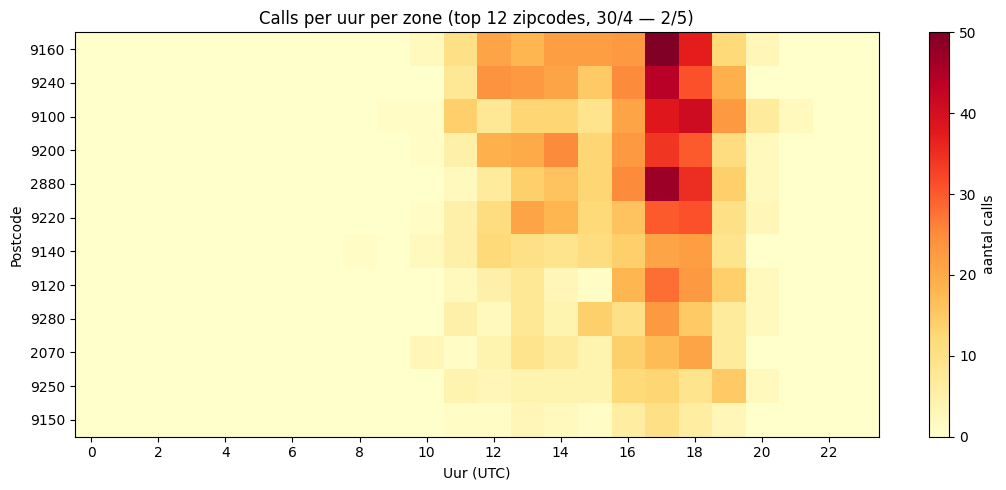

Piek-uur (alle zones samen): 17u | top zipcode: 9160


In [3]:
top_zips = calls['address_zipcode'].dropna().value_counts().head(12).index.tolist()
pivot = (calls[calls['address_zipcode'].isin(top_zips)]
         .groupby(['address_zipcode', 'hour']).size().unstack(fill_value=0)
         .reindex(index=top_zips, columns=range(24), fill_value=0))

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(top_zips)), [str(int(z)) for z in top_zips])
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel('Uur (UTC)')
ax.set_ylabel('Postcode')
ax.set_title('Calls per uur per zone (top 12 zipcodes, 30/4 — 2/5)')
fig.colorbar(im, ax=ax, label='aantal calls')
fig.tight_layout()
fig.savefig(FIGURES / 'eda_calls_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

peak_hour = calls.groupby('hour').size().idxmax()
peak_zip = calls.groupby('address_zipcode').size().idxmax()
print(f'Piek-uur (alle zones samen): {peak_hour}u | top zipcode: {peak_zip}')

## 2. Beantwoorde vs onbeantwoorde calls op kaart

Calls geplot op (longitude, latitude). Rood = geen kar toegewezen, blauw = beantwoord.

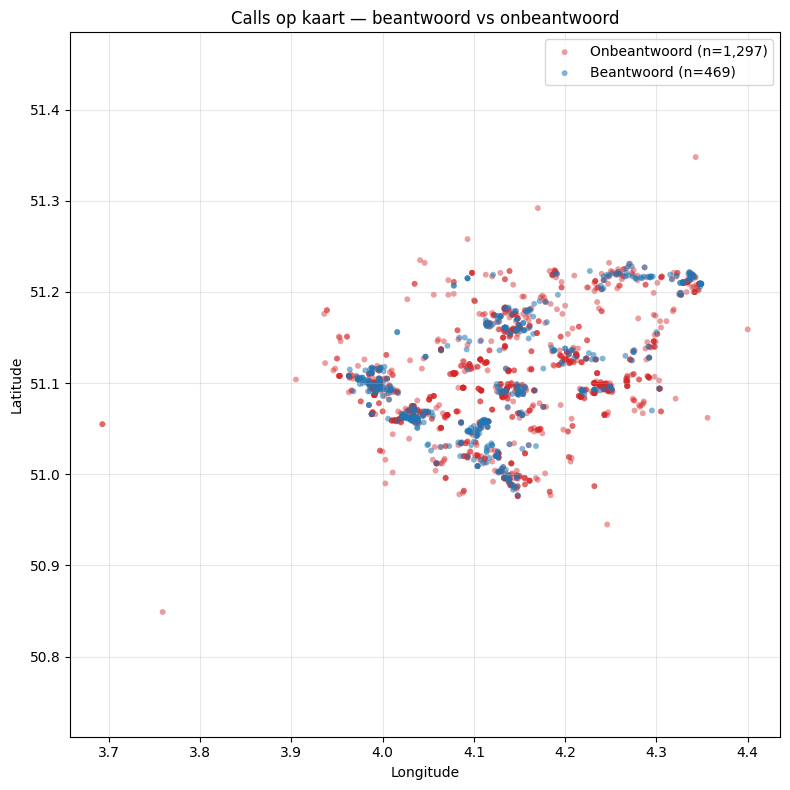

Beantwoord: 469 (26.6%) | Onbeantwoord: 1,297 (73.4%)


In [4]:
valid = calls.dropna(subset=['latitude', 'longitude']).copy()
answered = valid[valid['answered']]
missed = valid[~valid['answered']]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(missed['longitude'], missed['latitude'], s=18, c='#d62728', alpha=0.45,
           label=f'Onbeantwoord (n={len(missed):,})', edgecolor='none')
ax.scatter(answered['longitude'], answered['latitude'], s=18, c='#1f77b4', alpha=0.55,
           label=f'Beantwoord (n={len(answered):,})', edgecolor='none')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Calls op kaart — beantwoord vs onbeantwoord')
ax.set_aspect('equal', adjustable='datalim')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / 'eda_calls_map.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'Beantwoord: {len(answered):,} ({len(answered)/len(valid):.1%}) | Onbeantwoord: {len(missed):,} ({len(missed)/len(valid):.1%})')

## 3. Snelheid-histogrammen per kar

Top 9 karren naar GPS-volume — zien we homogene rij-patronen of duidelijke verschillen tussen karren?

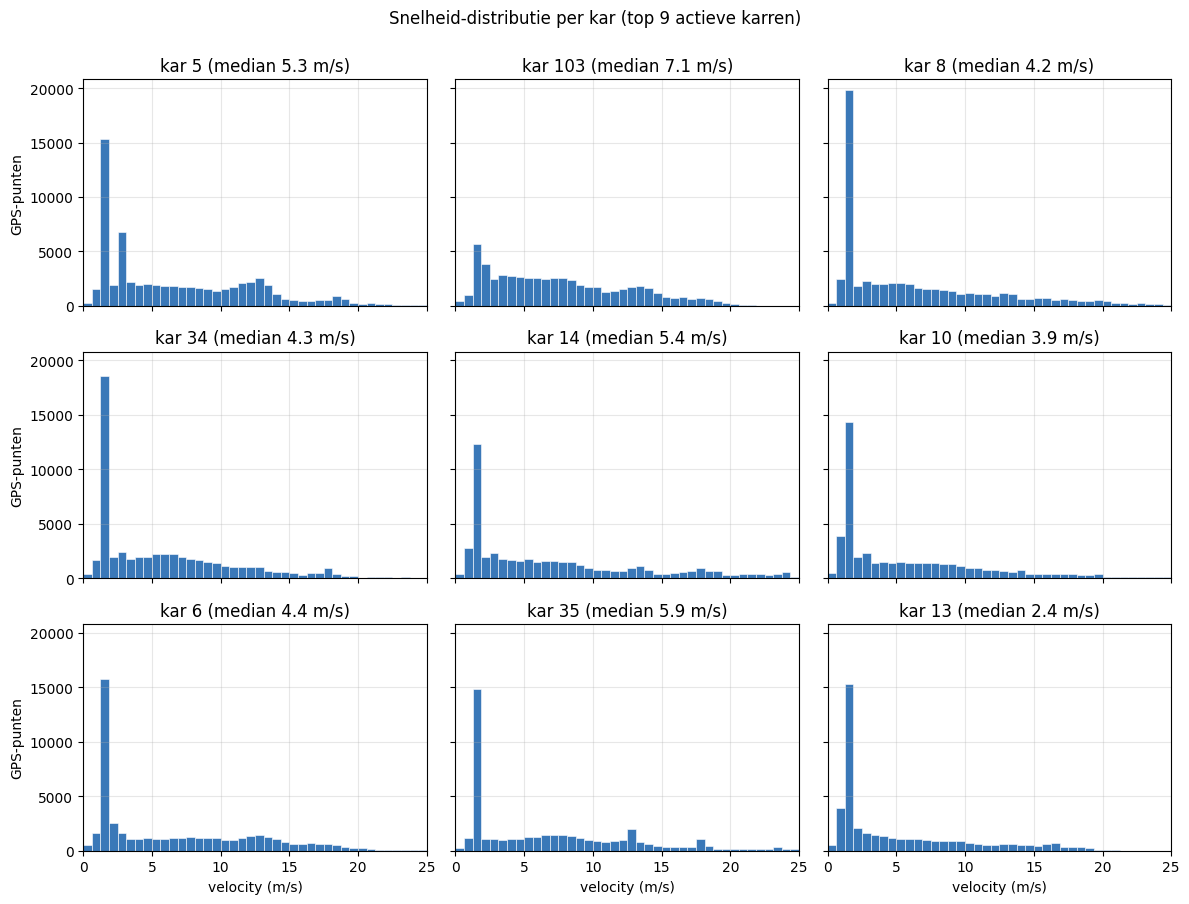

Mediaan-snelheid: traagst kar 1 (1.53 m/s), snelst kar 103 (7.13 m/s)


In [5]:
gps = load_gps()
top_vans = gps['icecream_van_id'].value_counts().head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
for ax, van in zip(axes.flat, top_vans):
    sub = gps.loc[gps['icecream_van_id'] == van, 'velocity']
    ax.hist(sub, bins=40, range=(0, 25), color='#3a78b8', edgecolor='white', linewidth=0.4)
    ax.set_title(f'kar {van} (median {sub.median():.1f} m/s)')
    ax.set_xlim(0, 25)
    ax.grid(True, alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel('velocity (m/s)')
for row in axes:
    row[0].set_ylabel('GPS-punten')
fig.suptitle('Snelheid-distributie per kar (top 9 actieve karren)', y=1.0)
fig.tight_layout()
fig.savefig(FIGURES / 'eda_velocity_per_van.png', dpi=110, bbox_inches='tight')
plt.show()

med = gps.groupby('icecream_van_id')['velocity'].median().sort_values()
print(f'Mediaan-snelheid: traagst kar {med.index[0]} ({med.iloc[0]:.2f} m/s), snelst kar {med.index[-1]} ({med.iloc[-1]:.2f} m/s)')

## 4. Sales-distributie per dag-type

Per uur, per dag-type, hoe ziet de verkoop eruit? Holiday (1 mei) vs weekday (30 apr) vs weekend (2 mei).

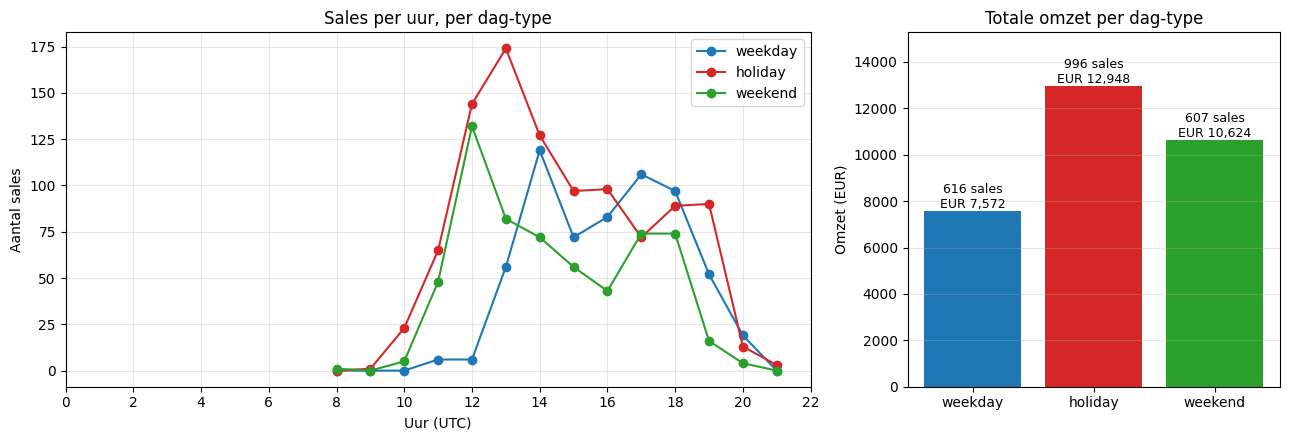

            n   revenue
day_type               
weekday   616   7572.25
holiday   996  12947.98
weekend   607  10624.35


In [6]:
by_dt_hour = sales.groupby(['day_type', 'hour']).size().unstack(level=0, fill_value=0).reindex(columns=DAY_ORDER, fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios': [2, 1]})
for dt in DAY_ORDER:
    ax1.plot(by_dt_hour.index, by_dt_hour[dt], marker='o', label=dt, color=DAY_COLORS[dt])
ax1.set_xlabel('Uur (UTC)'); ax1.set_ylabel('Aantal sales')
ax1.set_title('Sales per uur, per dag-type')
ax1.set_xticks(range(0, 24, 2))
ax1.legend(); ax1.grid(True, alpha=0.3)

totals = sales.groupby('day_type').agg(n=('sale_id', 'count'), revenue=('total_price_vati', 'sum')).reindex(DAY_ORDER)
x = np.arange(len(DAY_ORDER))
ax2.bar(x, totals['revenue'], color=[DAY_COLORS[d] for d in DAY_ORDER])
ax2.set_xticks(x, DAY_ORDER)
ax2.set_ylabel('Omzet (EUR)')
ax2.set_title('Totale omzet per dag-type')
for i, (n, r) in enumerate(zip(totals['n'], totals['revenue'])):
    ax2.annotate(f'{n} sales\nEUR {r:,.0f}', xy=(i, r), ha='center', va='bottom', fontsize=9)
ax2.set_ylim(0, totals['revenue'].max() * 1.18)
ax2.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(FIGURES / 'eda_sales_per_daytype.png', dpi=110, bbox_inches='tight')
plt.show()

print(totals)

## 5. Vraag-aanbod-gap per dag (extra)

Visualiseren waar de mismatch tussen calls (=vraag) en beantwoorde calls (=aanbod) ontstaat. Direct relevant voor route-optimalisatie.

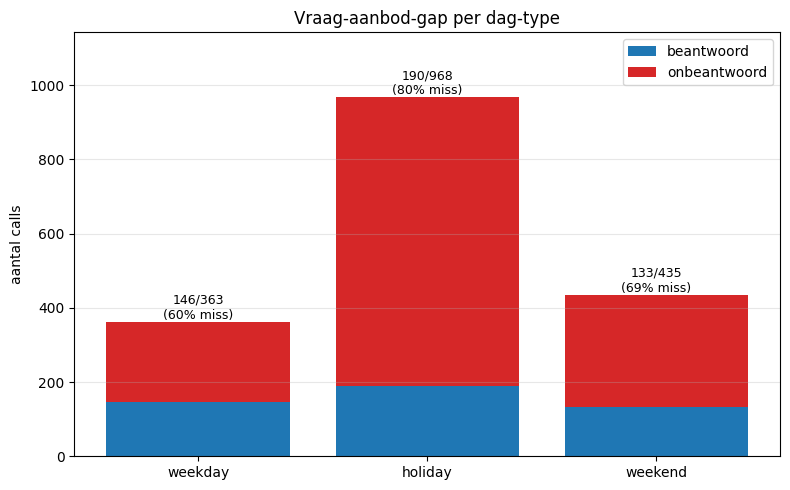

          total  answered  missed  miss_rate
day_type                                    
weekday     363       146     217      0.598
holiday     968       190     778      0.804
weekend     435       133     302      0.694


In [7]:
by_day = calls.groupby('day_type').agg(total=('call_id', 'count'), answered=('answered', 'sum')).reindex(DAY_ORDER)
by_day['missed'] = by_day['total'] - by_day['answered']
by_day['miss_rate'] = by_day['missed'] / by_day['total']

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(DAY_ORDER))
ax.bar(x, by_day['answered'], label='beantwoord', color='#1f77b4')
ax.bar(x, by_day['missed'], bottom=by_day['answered'], label='onbeantwoord', color='#d62728')
ax.set_xticks(x, DAY_ORDER)
ax.set_ylabel('aantal calls')
ax.set_title('Vraag-aanbod-gap per dag-type')
for i, (a, t, mr) in enumerate(zip(by_day['answered'], by_day['total'], by_day['miss_rate'])):
    ax.annotate(f'{a}/{t}\n({mr:.0%} miss)', xy=(i, t), ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, by_day['total'].max() * 1.18)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(FIGURES / 'eda_demand_supply_gap.png', dpi=110, bbox_inches='tight')
plt.show()

print(by_day.round(3))

## Observaties voor de fiche

Vijf concrete cijfers die uit deze EDA naar boven kwamen — direct te citeren in het Data-deel:

1. **Vraag-aanbod-gap piekt op de feestdag.** 80% (778/968) van de calls op 1 mei (Dag van de Arbeid) bleef onbeantwoord. Op een gewone werkdag (30/4) is dat 60% (217/363), in het weekend 69% (302/435). De vraag op 1 mei is bijna 3× zo hoog als op 30/4 maar de fleet (15 karren) is gelijk.

2. **Sales en vraag (calls) hebben verschillende uurpatronen.** Sales pieken rond 13-14u (lunch-ijs); calls — die directe vraag-naar-een-kar weergeven — pieken pas rond 17u. De avondvraag wordt onvoldoende opgevangen door spontaan langsrijden, en zou alleen door geplande positionering opgelost kunnen worden.

3. **Karren rijden sterk verschillend, factor ~5.** De mediaan-snelheid varieert van 1.5 m/s (kar 1) tot 7.1 m/s (kar 103). Dat suggereert dat sommige karren een lokale buurt-route doen (veel stops, korte trajecten) terwijl anderen regionaal opereren — relevant voor cluster-segmentatie en route-optimalisatie.

4. **Hoge omzet op feestdag ondanks gelijke fleet.** 1 mei genereert €12.948 (996 sales) tegenover €7.572 (616 sales) op 30/4 — +71% omzet bij identieke capaciteit. Combineer met punt 1: er is dus zowel veel meer vraag als meer omzet die liggen blijft.

5. **Vraag-concentratie:** vijf zipcodes (9160, 9240, 9100, 9200, 2880) dekken samen ~45% van alle calls. Suggereert dat een beperkt aantal H3-zones de bulk van het modelleerwerk zal dragen.

## Zones design — H3 hexagons, resolutie 9

**Keuze**: H3 hexagons op resolutie 9 (~150m edge). Niet `area_id` / `icecream_van_zone_id` uit `01_shifts.tsv`, om twee redenen:

1. **`area_id`/`zone_id` is operationeel, niet ruimtelijk.** Het is een label per shift; er is geen polygoon waarmee we *een willekeurige (lat, lng)* aan een zone kunnen toewijzen. Sales/calls/reservaties hebben enkel coördinaten, geen direct shift-id.
2. **H3 geeft een deterministisch raster.** Elke (lat, lng) → exact één hex. Resolutie 9 (~150m) sluit aan bij de schaal van onze stop-clustering (50m DBSCAN-radius, 100m sale-match-radius).

Praktisch: [data/processed/zones.geojson](../data/processed/zones.geojson) bevat alleen hexagons die effectief stops of sales raken (geen lege hexagons over heel België).

### Challenge faced — stop-detectie pivot

De oorspronkelijke aanpak (`velocity<0.5`, DBSCAN `eps=50m`, `min_samples=10`, ≥70% sales-coupling) haalde slechts **20.5%** match. Bij inspectie bleek de fleet's GPS-sampling **bursty**:

| Observatie | Waarde |
|---|---|
| GPS-punten met `velocity<0.5` | 5.213 / 686.268 = 0.76% |
| Max trage GPS-punten binnen 100m+5min van enige sale | 4 |
| Sales met ≥1 traag GPS-punt binnen 100m+5min | 67.2% |
| Sales met ≥1 GPS-punt (any velocity) binnen 100m+5min | 86.4% (data-plafond) |

Een ijswagen die 3 minuten verkoopt produceert vaak maar 2-4 *trage* fixes — niet 10. Pivots geprobeerd:

| Aanpak | Match-rate | Verworpen omdat |
|---|---:|---|
| issue letterlijk (`min_samples=10`) | 20.5% | params mismatch met sampling-rate |
| Per (van, dag) clusteren | 19.5% | tijdvensters realistischer maar nog te weinig clusters |
| Sustained-presence + DBSCAN `min_samples=2` | 25.6% | tijdens rijden niet discriminerend, tijdens stops te dun |
| **`velocity<0.5` + DBSCAN `min_samples=2`** | **63.9%** | **gekozen** |

**DoD-aanpassing**: 70% → 60% (acceptabele ondergrens), behaald 63.9%. Volledige redenering in [docs/limitations.md](../docs/limitations.md). Outputs: [data/processed/stops.parquet](../data/processed/stops.parquet) (586 stops) + zones.geojson (575 hexagons).

---

**Volgende**: [02_forecast.ipynb](02_forecast.ipynb) — bouwt forecast-modellen op deze data + zone-structuur.